In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-w857m6rq
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-w857m6rq
  Resolved https://www.github.com/mouseland/cellpose.git to commit a9f8bfcde43033247309e3982747df9fe9f09315
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 59.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 77.6 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.1-py3-none-any.whl size=213288 sha256=d5aefe2333fcfb275a7fde607323b8b0eadb58ef6bbb7a1d9d4b5f17da4e4c09
  Stored in directory: /tmp/pip-ephem-wheel-cache-cuj90onk/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [1]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [24]:
oc.upload_data()

In [13]:
oc.upload_scripts()

In [3]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tool
import pandas as pd


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [6]:

oc.upload_models()

In [1]:
import json

with open('./data/dataset_SB_splits.json', 'r') as f:
    splits = json.load(f)

ids_test  = splits['test']

print(f"Splits chargés : Test({len(ids_test)})")

Splits chargés : Test(15)


In [4]:
df_annotations = pd.read_csv('./data/Nuclei.csv')

Visualisation de l'image 280 avec ses annotations et sa segmentation SB


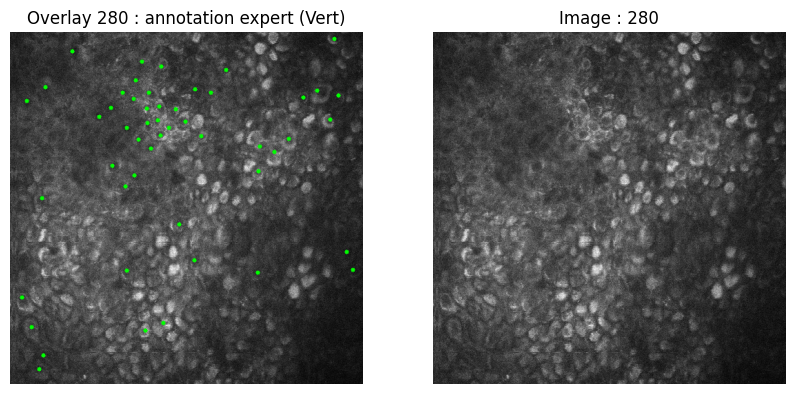

In [5]:
img_id = ids_test[12]
print(f"Visualisation de l'image {img_id} avec ses annotations et sa segmentation SB")  

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 10))
visualizer.plot_points_overlay(img_id, df_annotations, ax=ax1, show=False, prediction=False, annotation=True)
visualizer.plot(i=img_id, mode= 'Image', ax=ax2, show=False)
ax1.axis('off')
ax2.axis('off')
plt.show()  


Lancement de l'évaluation : raw_2channel_cellpose4...


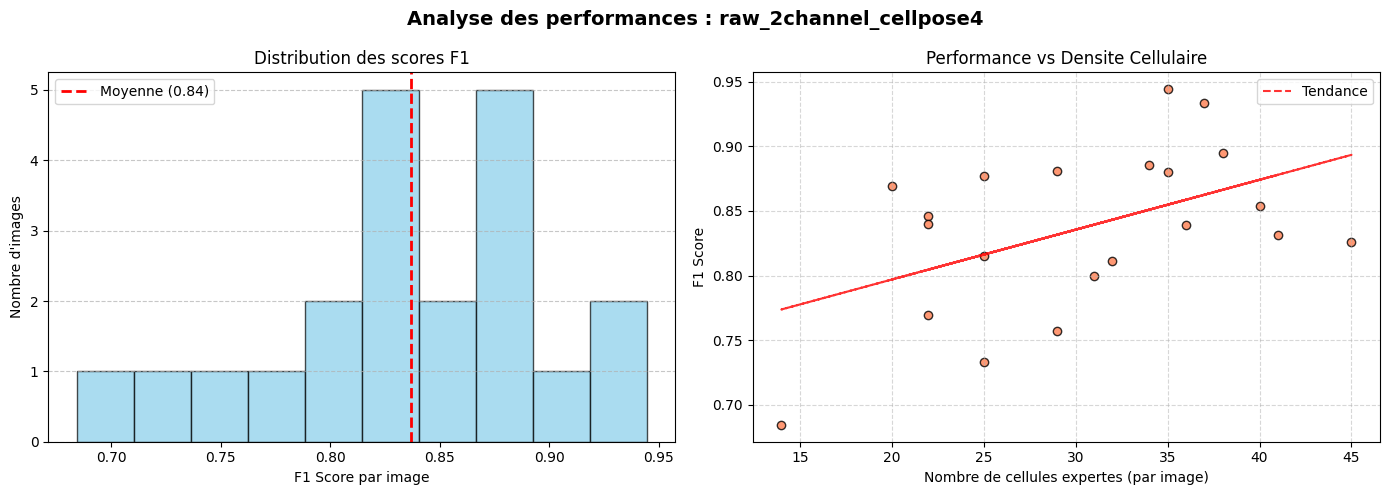


RESULTATS GLOBAUX : raw_2channel_cellpose4
Images evaluees          : 21
Total Vrais Positifs (TP): 584
Total Faux Positifs (FP) : 167
Total Faux Negatifs (FN) : 53
--------------------------------------------------
F1-Score Global (Micro)  : 0.841
F1-Score Moyen (Macro)   : 0.837



Lancement de l'évaluation : TopHat_2channel_cellpose4...


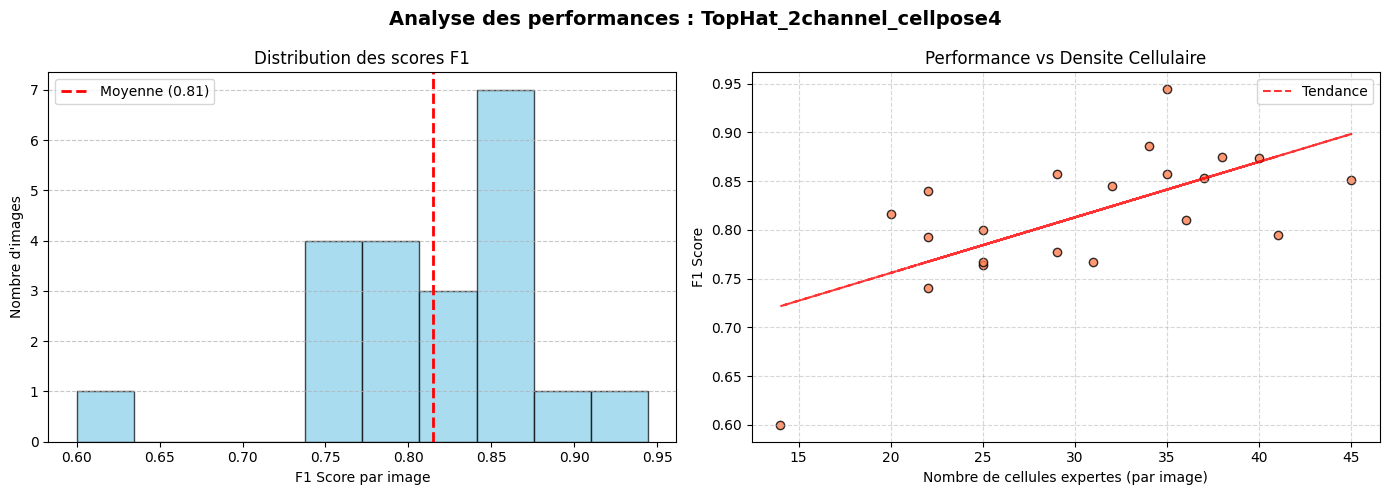


RESULTATS GLOBAUX : TopHat_2channel_cellpose4
Images evaluees          : 21
Total Vrais Positifs (TP): 581
Total Faux Positifs (FP) : 194
Total Faux Negatifs (FN) : 56
--------------------------------------------------
F1-Score Global (Micro)  : 0.823
F1-Score Moyen (Macro)   : 0.815



Lancement de l'évaluation : Nuclei_cellpose4...


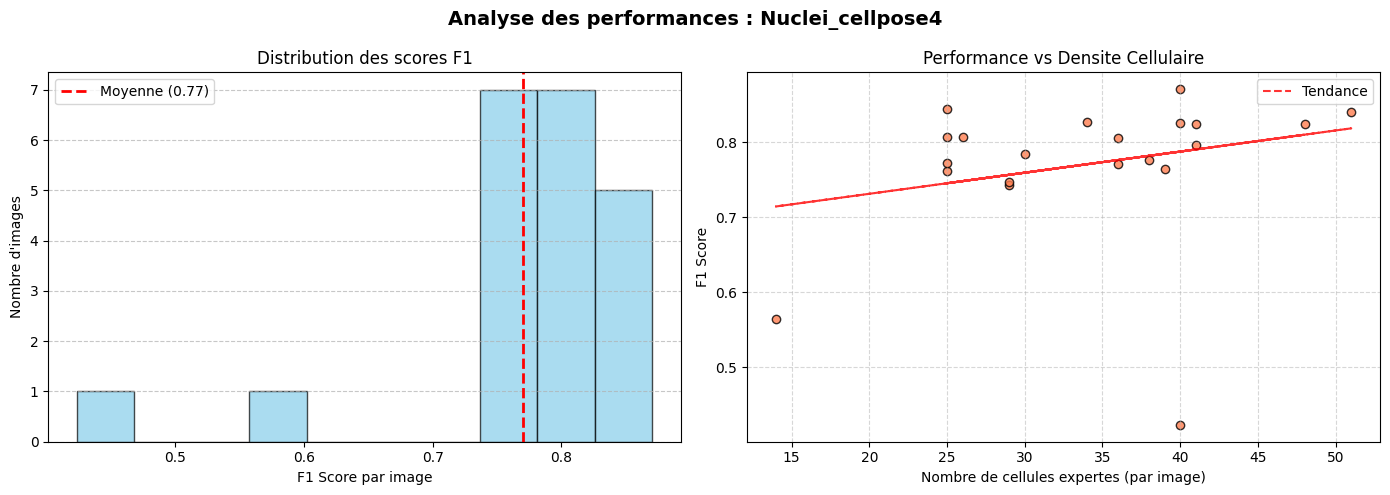


RESULTATS GLOBAUX : Nuclei_cellpose4
Images evaluees          : 21
Total Vrais Positifs (TP): 628
Total Faux Positifs (FP) : 283
Total Faux Negatifs (FN) : 84
--------------------------------------------------
F1-Score Global (Micro)  : 0.774
F1-Score Moyen (Macro)   : 0.770



Lancement de l'évaluation : 1channel_cellpose4...


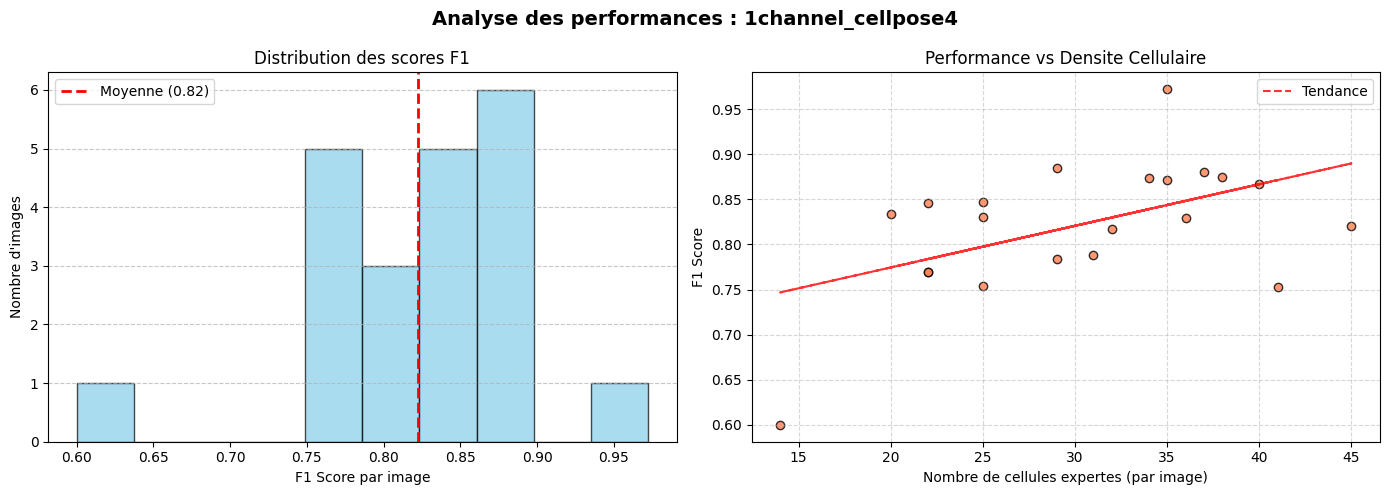


RESULTATS GLOBAUX : 1channel_cellpose4
Images evaluees          : 21
Total Vrais Positifs (TP): 586
Total Faux Positifs (FP) : 191
Total Faux Negatifs (FN) : 51
--------------------------------------------------
F1-Score Global (Micro)  : 0.829
F1-Score Moyen (Macro)   : 0.822



Génération des graphiques comparatifs finaux...


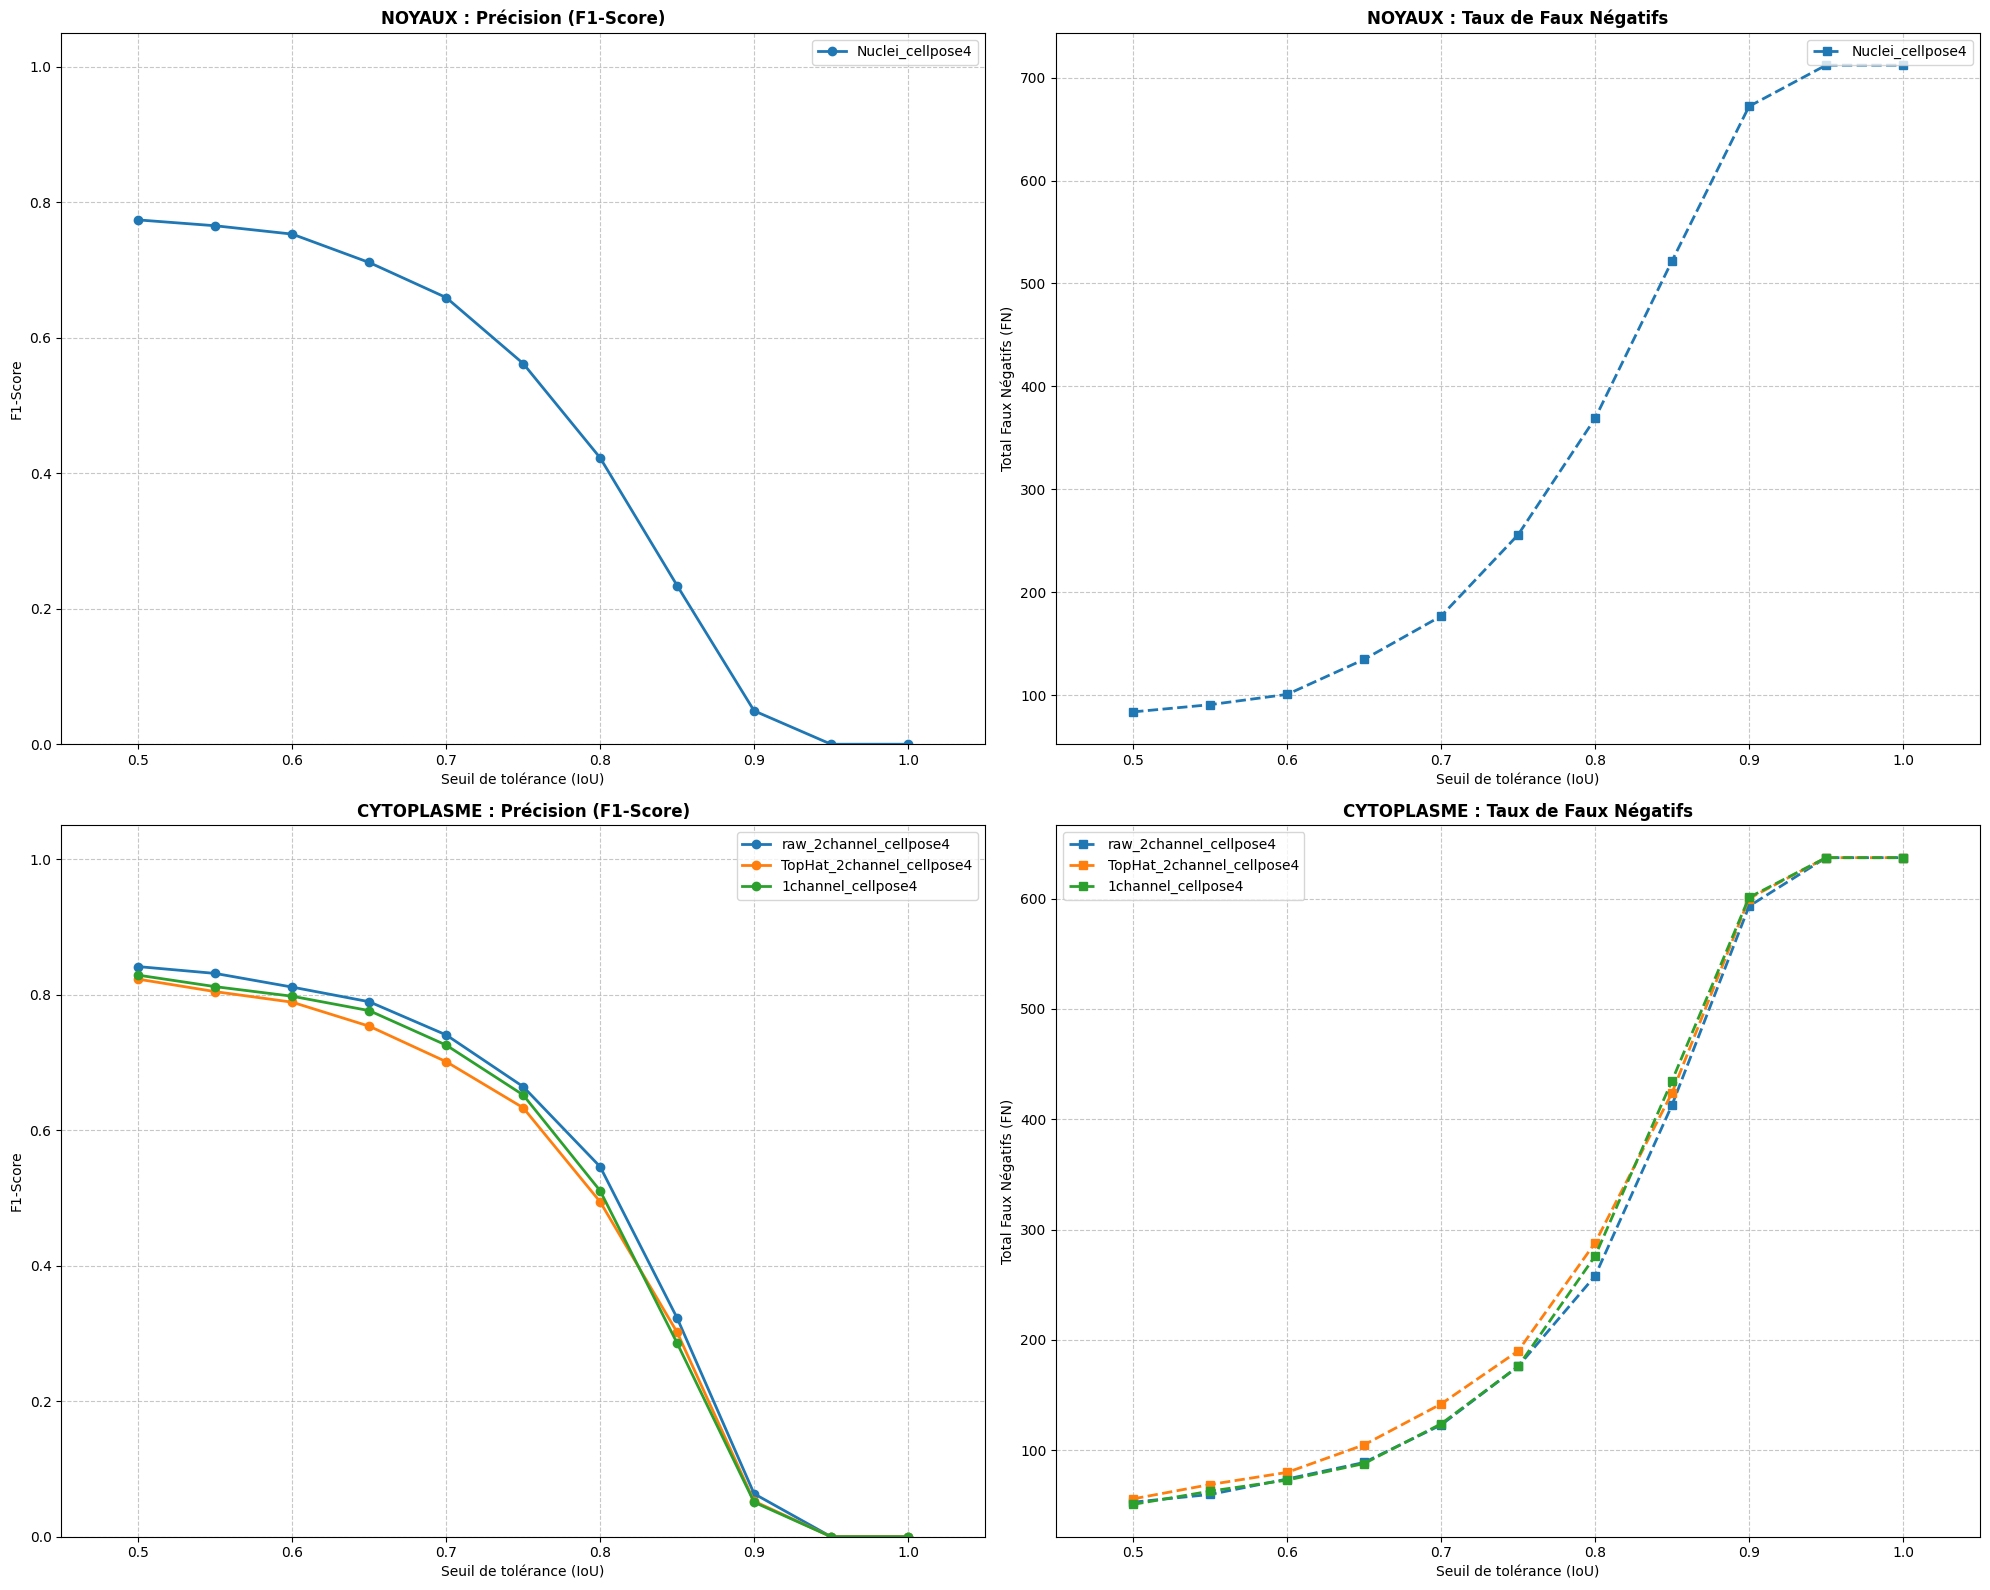


Exportation de l'intégralité du dossier benchmark...
Dossier benchmark_test envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test.zip
Export réussi vers : /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test

Évaluation terminée. Tous les résultats sont sauvegardés dans : /content/results/benchmark_test


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO 
from contextlib import redirect_stdout
from cellpose import models, io 

label = "Nuclei_cellpose4"
target = "Nuc"
load_method = "data"
mode = "Image"
param = {"channels": [0, 0], "flow_threshold": 0.4, "cellprob_threshold": -0.5}
model_path = "./models/cellpose4_nuclei.pth"


ev = tool.Stats()

base_output = os.path.abspath("./results/benchmark_SB")
os.makedirs(base_output, exist_ok=True)

donnees_pour_graphes = {}
model_root = os.path.join(base_output, label)
output_dir_masks = os.path.join(model_root, "masks")
output_dir_viz = os.path.join(model_root, "viz")

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

model = models.CellposeModel(gpu=True, pretrained_model=model_path)

all_results = []
masks_pred_list = []
Y_true_list = []

if load_method == "channel":
    X_val_multi, _ = visualizer.load_channel(ids_test, mode= mode)

for idx, img_id in enumerate(ids_test):
    if load_method == "channel":
        img = X_val_multi[idx]
        true_mask = df_annotations[df_annotations['Image'].astype(str).str.startswith(str(img_id))][['X', 'Y']].values[idx]
    else:
        img = visualizer.load_data(img_id, mode=mode)
        true_mask = df_annotations[df_annotations['Image'].astype(str).str.startswith(str(img_id))][['X', 'Y']].values[idx]

    masks, _, _ = model.eval(img, **param)

    masks_pred_list.append(masks)
    Y_true_list.append(true_mask)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_{target}_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    
    nom_rapport = f"{label}_{img_id}"
    
    perf = ev.summary_perf_point(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    ax1, ax2 = axes.flatten()
    
    visualizer.plot(i=img_id, mode= 'Image', ax=ax1, show=False)
    ax1.set_title(f"A. Image Entrée ")

    visualizer.plot_points_overlay(img_id, df_annotations,mask_pred=masks, ax=ax1, show=False, prediction=True, annotation=True)
    ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
    
    titre_rapport = (f"Rapport Image : {img_id} | F1-Score: {perf['f1']:.3f} | "
                    f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_viz.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    plt.close(fig)

# Capture et sauvegarde du rapport textuel global
f = StringIO()
with redirect_stdout(f):
    df_final = ev.global_report(all_results, model_name=label)
rapport_texte = f.getvalue()

# Affichage console et sauvegarde fichier
print(rapport_texte)
chemin_txt = os.path.join(model_root, f"resultats_globaux_{label}.txt")
with open(chemin_txt, "w") as text_file:
    text_file.write(rapport_texte)
# --- SAUVEGARDE DE L'UNIQUE GRAPHIQUE DE GLOBAL_REPORT ---
# Récupération de la figure active générée par global_report
fig_global = plt.gcf()

# Sauvegarde sous forme d'un seul fichier
chemin_graphe_global = os.path.join(model_root, f"global_report_plot_{label}.png")
fig_global.savefig(chemin_graphe_global, dpi=300, bbox_inches='tight')

# Nettoyage de la mémoire
plt.close('all')

# Stockage pour le graphique final
donnees_pour_graphes[label] = {
    "target": target,
    "y_true": Y_true_list,
    "masks_pred": masks_pred_list
}

# --- 3. AFFICHAGE ET SAUVEGARDE DU GRAPHIQUE COMPARATIF FINAL ---
print("\nGénération des graphiques comparatifs finaux...")

fig_comp, axes_comp = plt.subplots(2, 2, figsize=(20, 16))
(ax_nuc_f1, ax_nuc_fn), (ax_cyto_f1, ax_cyto_fn) = axes_comp

for label, data in donnees_pour_graphes.items():
    if data['target'] == "Nuc":
        current_axes_tuple = (ax_nuc_f1, ax_nuc_fn)
    else:
        current_axes_tuple = (ax_cyto_f1, ax_cyto_fn)

    ev.plot_f1_vs_iou(data['y_true'], data['masks_pred'], ax=current_axes_tuple, show=False)
    
    if current_axes_tuple[0].lines:
        current_axes_tuple[0].lines[-1].set_label(label)
        current_axes_tuple[1].lines[-1].set_label(label)

ax_nuc_f1.set_title("NOYAUX : Précision (F1-Score)", fontweight='bold')
ax_nuc_fn.set_title("NOYAUX : Taux de Faux Négatifs", fontweight='bold')
ax_cyto_f1.set_title("CYTOPLASME : Précision (F1-Score)", fontweight='bold')
ax_cyto_fn.set_title("CYTOPLASME : Taux de Faux Négatifs", fontweight='bold')

ax_nuc_f1.legend()
ax_nuc_fn.legend()
ax_cyto_f1.legend()
ax_cyto_fn.legend()

plt.tight_layout()

# Sauvegarde du graphique global dans le dossier benchmark
chemin_graphe_final = os.path.join(base_output, "benchmark_F1_vs_IoU.png")
plt.savefig(chemin_graphe_final, dpi=300, bbox_inches='tight')

plt.show()

# --- 4. EXPORT GLOBAL ---
print("\nExportation de l'intégralité du dossier benchmark...")
try:
    chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test"
    oc.download_path(base_output, chemin_export_global)
    print(f"Export réussi vers : {chemin_export_global}")
except Exception as e:
    print(f"Erreur lors de l'export global : {e}")

print(f"\nÉvaluation terminée. Tous les résultats sont sauvegardés dans : {base_output}")